## Modelos base para predicción de CO2

In [100]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

Se escoge sitio y variable ecológica para construir modelos base

In [101]:
sitio = "ABBY"
variable = "nee"

In [102]:
datos = pd.read_csv(
    "terrestrial_daily-targets.csv.gz",
    compression="gzip"
)

datos.head()

,project_id,site_id,datetime,duration,variable,observation
0,neon4cast,ABBY,2017-08-01T00:00:00Z,P1D,le,100.128007
1,neon4cast,ABBY,2017-08-01T00:00:00Z,P1D,nee,-3.643311
2,neon4cast,ABBY,2017-08-02T00:00:00Z,P1D,le,109.050018
3,neon4cast,ABBY,2017-08-02T00:00:00Z,P1D,nee,-1.303639
4,neon4cast,ABBY,2017-08-03T00:00:00Z,P1D,le,82.502284


In [103]:
datos_filtrados = datos[ (datos["site_id"] == sitio) & (datos["variable"] == variable) ].copy()

datos_filtrados.to_csv(
    "abby_nee.csv",
    index=False
)

datos_filtrados["datetime"] = pd.to_datetime(
    datos_filtrados["datetime"]
)

datos_filtrados

,project_id,site_id,datetime,duration,variable,observation
1,neon4cast,ABBY,2017-08-01 00:00:00+00:00,P1D,nee,-3.643311
3,neon4cast,ABBY,2017-08-02 00:00:00+00:00,P1D,nee,-1.303639
5,neon4cast,ABBY,2017-08-03 00:00:00+00:00,P1D,nee,-2.152446
7,neon4cast,ABBY,2017-08-04 00:00:00+00:00,P1D,nee,-4.297783
9,neon4cast,ABBY,2017-08-05 00:00:00+00:00,P1D,nee,-3.157422
...,...,...,...,...,...,...
3593,neon4cast,ABBY,2026-05-01 00:00:00+00:00,P1D,nee,-5.473924
3595,neon4cast,ABBY,2026-05-02 00:00:00+00:00,P1D,nee,-2.127104
3597,neon4cast,ABBY,2026-05-03 00:00:00+00:00,P1D,nee,-1.037478
3599,neon4cast,ABBY,2026-05-07 00:00:00+00:00,P1D,nee,-2.062098


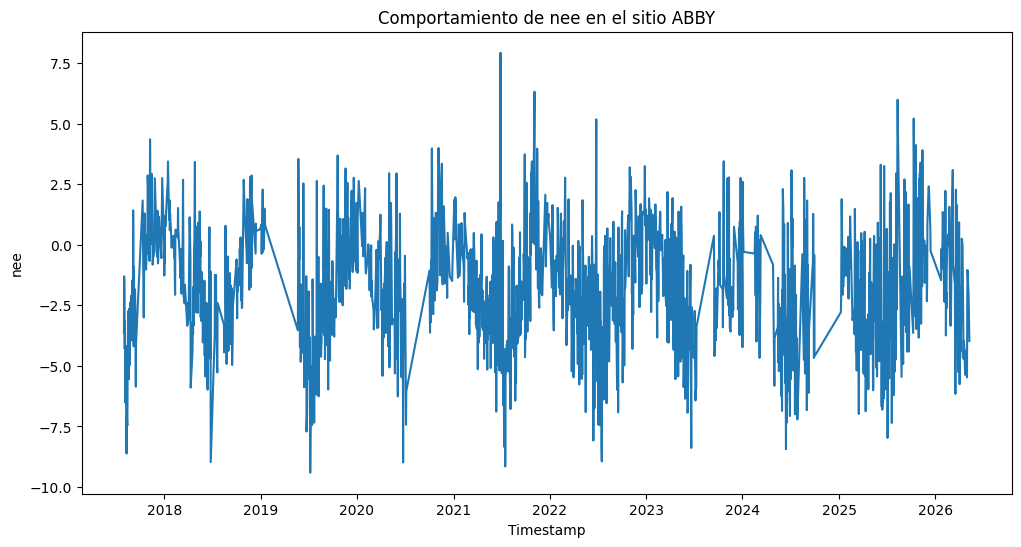

In [104]:
subset = datos_filtrados
plt.figure(figsize=(12, 6))
plt.plot(subset["datetime"], subset["observation"], linestyle='-')
plt.title(f'Comportamiento de {variable} en el sitio {sitio}')
plt.xlabel('Timestamp')
plt.ylabel(variable)
plt.show()

### modelos base

In [105]:
target = "observation"

In [106]:
datos = datos_filtrados.copy()

In [107]:
print(datos["datetime"].min())

print(datos["datetime"].max())

2017-08-01 00:00:00+00:00
2026-05-10 00:00:00+00:00


In [108]:
datos["datetime"] = pd.to_datetime(
    datos["datetime"]
)

In [109]:
datos["lag1"] = datos["observation"].shift(1)
datos["lag2"] = datos["observation"].shift(2)
datos["lag7"] = datos["observation"].shift(7)

datos["day_of_year"] = datos["datetime"].dt.dayofyear
datos["month"] = datos["datetime"].dt.month
datos["day"] = datos["datetime"].dt.day

datos = datos.dropna().reset_index(drop=True)

In [110]:
datos_train = datos[datos["datetime"] < "2026-01-01"]

datos_test = datos[datos["datetime"] >= "2026-01-01"]

In [111]:
datos["lag1"] = datos["observation"].shift(1)
datos["lag2"] = datos["observation"].shift(2)
datos["lag7"] = datos["observation"].shift(7)

datos["day_of_year"] = datos["datetime"].dt.dayofyear
datos["month"] = datos["datetime"].dt.month
datos["day"] = datos["datetime"].dt.day

datos = datos.dropna().reset_index(drop=True)

In [112]:
columnas_modelo = [
    "day_of_year",
    "month",
    "day",
    "lag1",
    "lag2",
    "lag7",

    "observation"
]

datos_modelo = datos[columnas_modelo]

In [115]:
train_modelo = datos_train[columnas_modelo].dropna()
test_modelo = datos_test[columnas_modelo].dropna()

In [117]:
X_train = train_modelo.loc[:, train_modelo.columns != "observation"]
y_train = train_modelo["observation"].to_numpy()

X_test = test_modelo.loc[:, test_modelo.columns != "observation"]
y_test = test_modelo["observation"].to_numpy()

In [118]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [119]:
xgbr = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

xgbr.fit(X_train, y_train)

y_pred_xgb = xgbr.predict(X_test)

In [123]:
def metricas(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nombre,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [124]:
resultados_2026 = pd.DataFrame([

    metricas("Random Forest", y_test, y_pred_rf),

    metricas("XGBoost", y_test, y_pred_xgb)

])

resultados_2026

,Modelo,RMSE,MAE,R2
0,Random Forest,1.860960,1.535551,0.311113
1,XGBoost,1.871665,1.517638,0.303164


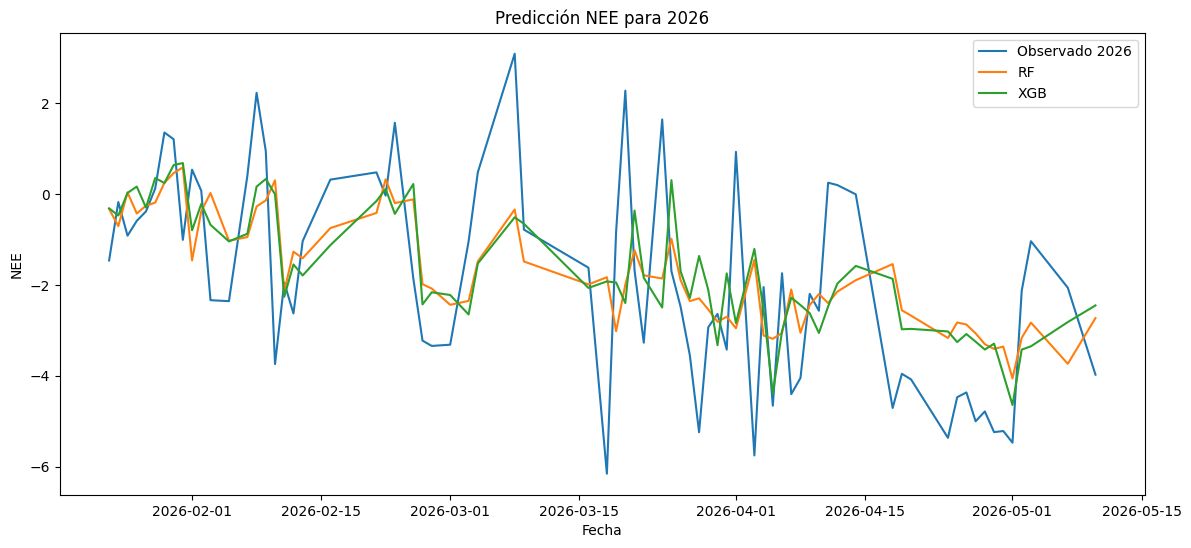

In [125]:
plt.figure(figsize=(14,6))

plt.plot(datos_test["datetime"].iloc[:len(y_test)], y_test,label="Observado 2026")
plt.plot(datos_test["datetime"].iloc[:len(y_test)], y_pred_rf, label="RF")
plt.plot(datos_test["datetime"].iloc[:len(y_test)], y_pred_xgb, label="XGB")

plt.xlabel("Fecha")
plt.ylabel("NEE")

plt.title("Predicción NEE para 2026")
plt.legend()

plt.show()